In [1]:
# 加载所需要的包
%matplotlib inline

# scitnific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

import warnings
warnings.filterwarnings('ignore') 

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# 加载模型
match_task_m2 = hddm.load('match_task_m2.hddm')
rdk_task_m3 = hddm.load('rdk_task_m3.hddm')

## 匹配任务

### p1：不同难度下，自我与他人v的后验分布，分不同组

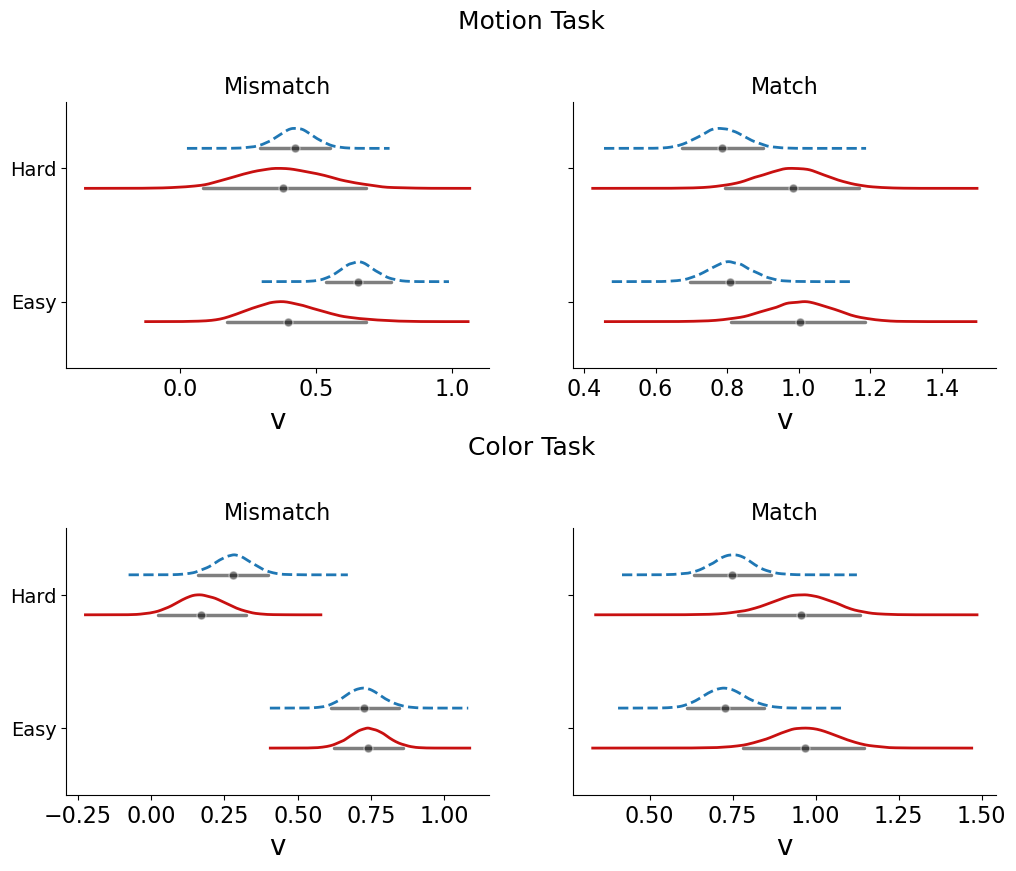

In [5]:
# ========================== 提取后验样本 ==========================
samples = match_task_m2.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept'] # 以颜色，匹配，他人，容易为基线
v_association_self = samples['v_association[T.self]']
v_group_motion = samples['v_group[T.motion]']
v_association_group_motion = samples['v_association[T.self]:group[T.motion]']
v_stim = samples['v_stim']
v_association_stim = samples['v_association[T.self]:stim']
v_stim_group_motion = samples['v_stim:group[T.motion]']
v_association_stim_group_motion = samples['v_association[T.self]:stim:group[T.motion]']
v_difficulty = samples['v_difficulty']
v_association_difficulty = samples['v_association[T.self]:difficulty']
v_difficulty_group_motion = samples['v_difficulty:group[T.motion]']
v_association_difficulty_group_motion = samples['v_association[T.self]:difficulty:group[T.motion]']
v_stim_difficulty = samples['v_stim:difficulty']
v_association_stim_difficulty = samples['v_association[T.self]:stim:difficulty']
v_stim_difficulty_group_motion = samples['v_stim:difficulty:group[T.motion]']
v_association_stim_difficulty_group_motion = samples['v_association[T.self]:stim:difficulty:group[T.motion]']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

# 分组：color（基线）、motion
for group in ['color', 'motion']:
    for stim_cond in ['Match', 'Mismatch']:
        for diff_level in [0, 1]:  # 难度只有 2 水平：0 / 1
            for assoc_cond in ['Other', 'Self']:
                
                n_diff_add = diff_level  # 0=easy,1=hard 直接用，不用 -1
                v = None
                
                # 基线（color 组）
                if stim_cond == 'Match':
                    if assoc_cond == 'Other':
                        base = (v_Intercept + v_stim) + (n_diff_add * v_difficulty)
                    else:
                        base = (v_Intercept + v_stim + v_association_self + v_association_stim) + \
                               (n_diff_add * (v_difficulty + v_association_difficulty))
                else: # Mismatch
                    if assoc_cond == 'Other':
                        base = (v_Intercept + v_stim) + \
                               (n_diff_add * (v_difficulty + v_stim_difficulty))
                    else:
                        base = (v_Intercept + v_stim + v_association_self) + \
                               (n_diff_add * (v_difficulty + v_association_difficulty + v_stim_difficulty + v_association_stim_difficulty))
                
                # motion 组加上交互项
                if group == 'motion':
                    if stim_cond == 'Match':
                        if assoc_cond == 'Other':
                            motion_add = v_group_motion + (n_diff_add * v_difficulty_group_motion)
                        else:
                            motion_add = (v_group_motion + v_association_group_motion) + \
                                         (n_diff_add * (v_difficulty_group_motion + v_association_difficulty_group_motion))
                    else: # Mismatch
                        if assoc_cond == 'Other':
                            motion_add = v_group_motion + v_stim_group_motion + \
                                         (n_diff_add * (v_difficulty_group_motion + v_stim_difficulty_group_motion))
                        else:
                            motion_add = (v_group_motion + v_stim_group_motion + v_association_group_motion) + \
                                         (v_association_stim_group_motion) + \
                                         (n_diff_add * (v_association_stim_difficulty_group_motion+ v_stim_difficulty_group_motion + v_association_difficulty_group_motion + v_association_stim_difficulty_group_motion))
                    v = base + motion_add
                else:
                    v = base
                
                conditions.append({
                    'group': group,
                    'stim': stim_cond,
                    'difficulty': diff_level,
                    'association': assoc_cond,
                    'v_samples': v.values
                })

# ========================== 绘图 ==========================
color_self = "#c81010"    # 红色
color_other = "#1f77b4"  # 蓝色
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.15
offset_other = 0.15
scale = 0.15

# 2行×2列
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=True, dpi=100)
groups = ['motion', 'color']
stim_list = ['Mismatch', 'Match']

# 扩大行距
plt.subplots_adjust(hspace=0.6)

for row_idx, group in enumerate(groups):
    for col_idx, stim in enumerate(stim_list):
        ax = axes[row_idx, col_idx]
        conds = [c for c in conditions if c['group'] == group and c['stim'] == stim]
        
        # 绘制密度脊线 🔥 只循环 0 和 1
        for diff in [0, 1]:
            for assoc in ['Self', 'Other']:
                match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
                if not match: continue
                v_data = match[0]['v_samples']
                
                kde = gaussian_kde(v_data, bw_method='scott')
                v_vals = np.linspace(v_data.min() - 0.1, v_data.max() + 0.1, 300)
                density = kde(v_vals)
                density_norm = (density / density.max()) * scale
                
                base_y = diff + 1 + (offset_self if assoc == 'Self' else offset_other)
                y_upper = base_y + density_norm
                
                line_color = color_self if assoc == 'Self' else color_other
                ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2)
        
        # 均值点 & HDI 🔥 只循环 0 和 1
        for diff in [0, 1]:
            for assoc in ['Self', 'Other']:
                match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
                if not match: continue
                v_data = match[0]['v_samples']
                mean_v = v_data.mean()
                hdi_low, hdi_high = np.percentile(v_data, [3, 97])
                y = diff + 1 + (offset_self if assoc == 'Self' else offset_other)
                
                ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.5, linewidth=2.5, solid_capstyle='round')
                ax.scatter(mean_v, y, color='black', alpha=0.5, s=40, edgecolor='white', linewidth=1, zorder=5)
        
        # 装饰
        ax.set_title(f'{stim}', fontsize=16)
        ax.set_xlabel('v', fontsize=20)
        ax.tick_params(axis='x', labelsize=16)
        
        # 🔥 Y 轴只显示 2 个水平：Easy / Hard
        ax.set_yticks([1, 2])
        ax.set_yticklabels(['Easy', 'Hard'], fontsize=14)
        ax.set_ylim(0.5, 2.5)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# ========== 关键：在整图最顶端加行标签 Motion / Color ==========
# 给每一行加组标签
axes[0,0].text(1.1, 1.3, 'Motion Task', fontsize=18, ha='center', va='center', transform=axes[0,0].transAxes)
axes[1,0].text(1.1, 1.3, 'Color Task', fontsize=18, ha='center', va='center', transform=axes[1,0].transAxes)

# 图例
# legend_elements = [
#     Line2D([0], [0], color=color_self, lw=2.5, linestyle='-', label='Self'),
#     Line2D([0], [0], color=color_other, lw=2.5, linestyle='--', label='Other')
# ]
# fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.03, 0.97), fontsize=16, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0])
# plt.savefig('Fig/match_v_2level.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

### p2：偏差参数

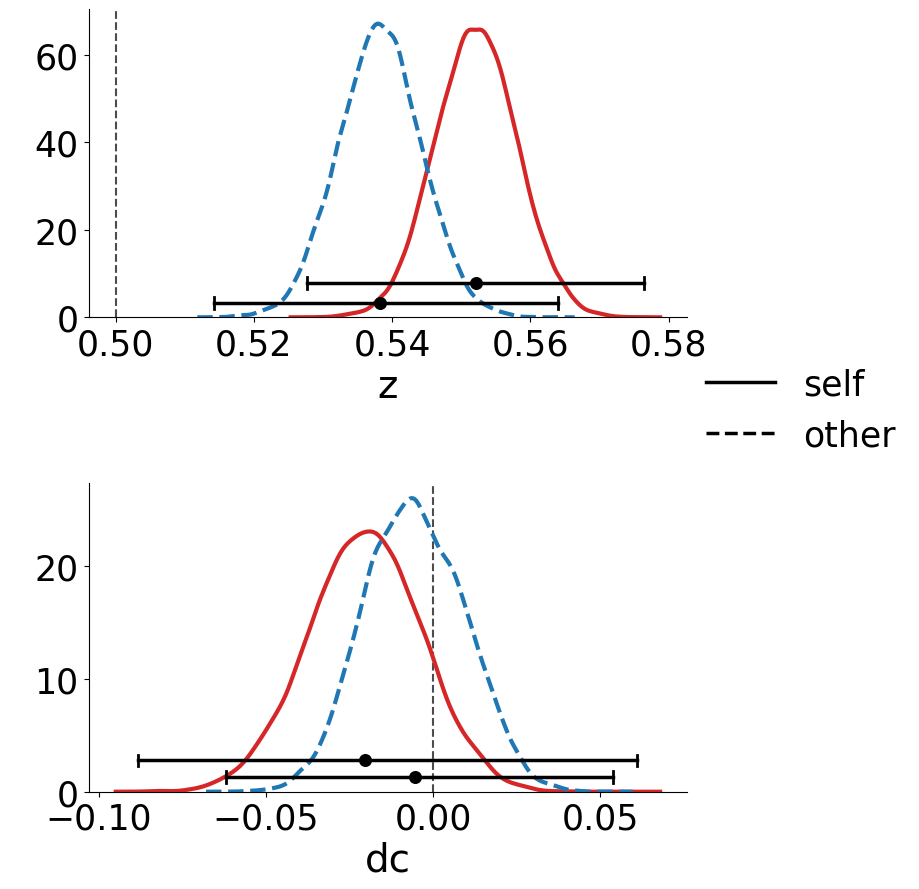

In [3]:
# =====================
# 1. 数据计算
# =====================
trace = match_task_m2.get_traces()

# z (转换后)
z_self = 1 / (1 + np.exp(-trace["z_trans(self)"]))
z_other = 1 / (1 + np.exp(-trace["z_trans(other)"]))

# dc (不用转换)
v_intercept = (trace["v_Intercept"] + trace["v_group[T.motion]"])/2
v_self_effect = (trace["v_association[T.self]"] + trace["v_association[T.self]:group[T.motion]"])/2
dc_other = v_intercept
dc_self  = v_intercept + v_self_effect

# =====================
# 2. HDI 函数
# =====================
def hdi(samples, prob=0.95):
    sorted_samples = np.sort(samples)
    n = len(samples)
    gap = int(n * prob)
    min_hdi = sorted_samples[:n-gap].min()
    max_hdi = sorted_samples[gap:].max()
    return min_hdi, max_hdi

# =====================
# 3. 绘图函数
# =====================
def plot_posterior(ax, data, color, label, is_self):
    linestyle = "-" if is_self else "--"
    
    kde_plot = sns.kdeplot(data, color=color, linewidth=3, linestyle=linestyle, ax=ax, label=label)
    kde_line = kde_plot.lines[-1]
    y_max = kde_line.get_ydata().max()
    
    y_hdi = y_max * 0.12 if is_self else y_max * 0.05
    
    mean_val = np.mean(data)
    h_low, h_high = hdi(data)
    
    ax.scatter(mean_val, y_hdi, color="black", s=70, zorder=5)
    ax.plot([h_low, h_high], [y_hdi, y_hdi], color="black", linewidth=2.5, zorder=4)
    ax.plot([h_low, h_low], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)
    ax.plot([h_high, h_high], [y_hdi-0.02*y_max, y_hdi+0.02*y_max], color="black", linewidth=2)

# =====================
# 4. 画图（全中文 + 无框线 + 无网格 + 统一红蓝）
# =====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

# --------------------
# 子图1：z 决策偏差
# --------------------
ax1.axvline(0.5, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax1, z_self, "#d62728", "self", is_self=True)
plot_posterior(ax1, z_other, "#1f77b4", "other", is_self=False)

ax1.set_xlabel("z", fontsize=28)
ax1.set_ylabel(" ", fontsize=14)
ax1.tick_params(axis='x', labelsize=25)
ax1.tick_params(axis='y', labelsize=25)
# ax1.set_title("决策偏差后验分布", fontsize=15, weight="bold")
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, linestyle='-', label='self'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='other')
]
ax1.legend(handles=legend_elements, fontsize=25, frameon=False, loc='right', bbox_to_anchor=(1.4, -0.3))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)

# --------------------
# 子图2：dc 漂移率
# --------------------
ax2.axvline(0, linestyle="--", c="black", alpha=0.7, linewidth=1.5)
plot_posterior(ax2, dc_self, "#d62728", "self", is_self=True)
plot_posterior(ax2, dc_other, "#1f77b4", "other", is_self=False)

ax2.set_xlabel("dc", fontsize=28)
ax2.set_ylabel(" ", fontsize=14)
ax2.tick_params(axis='x', labelsize=25)
ax2.tick_params(axis='y', labelsize=25)
# ax2.set_title("漂移率后验分布", fontsize=15, weight="bold")
# ax2.legend(fontsize=16, frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.savefig('Fig/match_bias.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# 计算所有数值
z1_low, z1_high = hdi(z_self)
z2_low, z2_high = hdi(z_other)
dc1_low, dc1_high = hdi(dc_self)
dc2_low, dc2_high = hdi(dc_other)

z1_mean = np.mean(z_self)
z2_mean = np.mean(z_other)
dc1_mean = np.mean(dc_self)
dc2_mean = np.mean(dc_other)

# 输出（均值 + 95% HDI）
print("======================")
print(f"z(self)   均值 = {z1_mean:.3f}  |  95% HDI = [{z1_low:.3f}, {z1_high:.3f}]")
print(f"z(other)  均值 = {z2_mean:.3f}  |  95% HDI = [{z2_low:.3f}, {z2_high:.3f}]")
print("----------------------")
print(f"dc(self)  均值 = {dc1_mean:.3f}  |  95% HDI = [{dc1_low:.3f}, {dc1_high:.3f}]")
print(f"dc(other) 均值 = {dc2_mean:.3f}  |  95% HDI = [{dc2_low:.3f}, {dc2_high:.3f}]")
print("======================")

z(self)   均值 = 0.552  |  95% HDI = [0.528, 0.576]
z(other)  均值 = 0.538  |  95% HDI = [0.514, 0.564]
----------------------
dc(self)  均值 = -0.020  |  95% HDI = [-0.088, 0.061]
dc(other) 均值 = -0.006  |  95% HDI = [-0.062, 0.054]


## 辨别任务

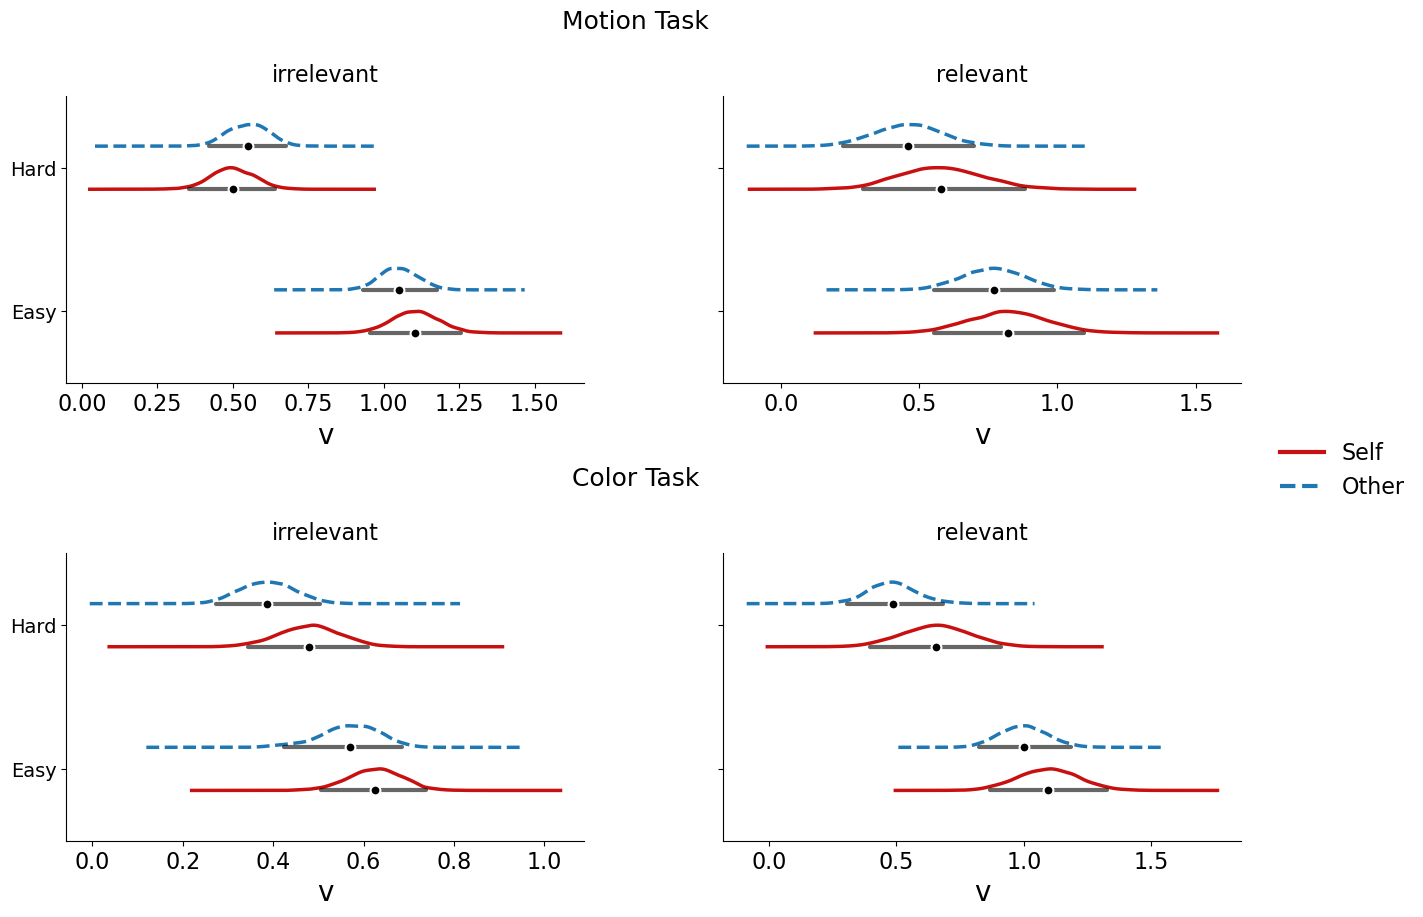

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# ========================== 提取后验样本 ==========================
samples = rdk_task_m3.posterior_trace_df

# 提取单个系数变量
v_Intercept = samples['v_Intercept']
v_association_self = samples['v_association[T.self]']
v_group_motion = samples['v_group[T.motion]']
v_association_group_motion = samples['v_association[T.self]:group[T.motion]']
v_relevant = samples['v_task_type[T.relevant]']
v_association_relevant = samples['v_association[T.self]:task_type[T.relevant]']
v_relevant_group_motion = samples['v_task_type[T.relevant]:group[T.motion]']
v_association_relevant_group_motion = samples['v_association[T.self]:task_type[T.relevant]:group[T.motion]']
v_difficulty = samples['v_difficulty']
v_association_difficulty = samples['v_association[T.self]:difficulty']
v_difficulty_group_motion = samples['v_difficulty:group[T.motion]']
v_association_difficulty_group_motion = samples['v_association[T.self]:difficulty:group[T.motion]']
v_relevant_difficulty = samples['v_task_type[T.relevant]:difficulty']
v_association_relevant_difficulty = samples['v_association[T.self]:task_type[T.relevant]:difficulty']
v_relevant_difficulty_group_motion = samples['v_task_type[T.relevant]:difficulty:group[T.motion]']
v_association_relevant_difficulty_group_motion = samples['v_association[T.self]:task_type[T.relevant]:difficulty:group[T.motion]']

# ========================== 计算不同条件下的v值 ==========================
conditions = []

for group in ['color', 'motion']:
    for relevant_cond in ['irrelevant', 'relevant']:
        for diff_level in [0, 1]:
            for assoc_cond in ['Other', 'Self']:
                
                n_diff_add = diff_level
                v = None
                
                # 基线 color
                if relevant_cond == 'irrelevant':
                    if assoc_cond == 'Other':
                        base = v_Intercept + (n_diff_add * v_difficulty)
                    else:
                        base = (v_Intercept + v_association_self) + \
                               (n_diff_add * (v_difficulty + v_association_difficulty))
                else:
                    if assoc_cond == 'Other':
                        base = (v_Intercept + v_relevant) + \
                               (n_diff_add * (v_difficulty + v_relevant_difficulty))
                    else:
                        base = (v_Intercept + v_relevant + v_association_self + v_association_relevant) + \
                               (n_diff_add * (v_difficulty + v_association_difficulty + v_relevant_difficulty + v_association_relevant_difficulty))
                
                # motion 交互项
                if group == 'motion':
                    if relevant_cond == 'irrelevant':
                        if assoc_cond == 'Other':
                            motion_add = v_group_motion + (n_diff_add * v_difficulty_group_motion)
                        else:
                            motion_add = (v_group_motion + v_association_group_motion) + \
                                         (n_diff_add * (v_difficulty_group_motion + v_association_difficulty_group_motion))
                    else:
                        if assoc_cond == 'Other':
                            motion_add = (v_group_motion + v_relevant_group_motion) + \
                                         (n_diff_add * (v_difficulty_group_motion + v_relevant_difficulty_group_motion))
                        else:
                            motion_add = (v_group_motion + v_relevant_group_motion + 
                                         v_association_group_motion + v_association_relevant_group_motion) + \
                                         (n_diff_add * (v_difficulty_group_motion + v_association_difficulty_group_motion +
                                                       v_relevant_difficulty_group_motion + v_association_relevant_difficulty_group_motion))
                    v = base + motion_add
                else:
                    v = base
                
                conditions.append({
                    'group': group,
                    'relevant': relevant_cond,
                    'difficulty': diff_level,
                    'association': assoc_cond,
                    'v_samples': v.values
                })

# ========================== 绘图 ==========================
color_self = "#c81010"
color_other = "#1f77b4"
linestyles = {'Self': '-', 'Other': '--'}

offset_self = -0.15
offset_other = 0.15
scale = 0.15

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=False, sharey=True, dpi=100)
groups = ['motion', 'color']
task_list = ['irrelevant', 'relevant']

plt.subplots_adjust(hspace=0.6)

for row_idx, group in enumerate(groups):
    for col_idx, task in enumerate(task_list):
        ax = axes[row_idx, col_idx]
        
        conds = [c for c in conditions if c['group'] == group and c['relevant'] == task]
        
        for diff in [0, 1]:
            for assoc in ['Self', 'Other']:
                task_match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
                if not task_match:
                    continue
                
                v_data = task_match[0]['v_samples']
                
                kde = gaussian_kde(v_data, bw_method='scott')
                v_vals = np.linspace(v_data.min() - 0.2, v_data.max() + 0.2, 300)
                density = kde(v_vals)
                density_norm = (density / density.max()) * scale
                
                base_y = diff + 1 + (offset_self if assoc == 'Self' else offset_other)
                y_upper = base_y + density_norm
                
                line_color = color_self if assoc == 'Self' else color_other
                ax.plot(v_vals, y_upper, color=line_color, linestyle=linestyles[assoc], linewidth=2.5)

        for diff in [0, 1]:
            for assoc in ['Self', 'Other']:
                task_match = [c for c in conds if c['difficulty'] == diff and c['association'] == assoc]
                if not task_match:
                    continue
                
                v_data = task_match[0]['v_samples']
                mean_v = v_data.mean()
                hdi_low, hdi_high = np.percentile(v_data, [2.5, 97.5])
                y = diff + 1 + (offset_self if assoc == 'Self' else offset_other)
                
                ax.plot([hdi_low, hdi_high], [y, y], color='black', alpha=0.6, linewidth=3, solid_capstyle='round')
                ax.scatter(mean_v, y, color='black', s=50, edgecolor='white', linewidth=1.5, zorder=5)

        # 添加标题
        ax.set_title(f'{task}', fontsize=16, pad=10)
        ax.set_xlabel('v', fontsize=20)
        ax.tick_params(axis='x', labelsize=16)
        
        ax.set_yticks([1, 2])
        ax.set_yticklabels(['Easy', 'Hard'], fontsize=14)
        ax.set_ylim(0.5, 2.5)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# ========== 修复5：标题放在每行顶端正中间 ==========
axes[0,0].text(1.1, 1.3, 'Motion Task', fontsize=18, ha='center', va='top', transform=axes[0,0].transAxes)
axes[1,0].text(1.1, 1.3, 'Color Task', fontsize=18, ha='center', va='top', transform=axes[1,0].transAxes)

# 图例
legend_elements = [
    Line2D([0], [0], color=color_self, lw=3, linestyle='-', label='Self'),
    Line2D([0], [0], color=color_other, lw=3, linestyle='--', label='Other')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.1, 0.5), fontsize=16, frameon=False)

# 正确布局
plt.tight_layout(rect=[0, 0, 0.97, 0.93])
plt.savefig('Fig/rdk_v_final.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()